In [1]:
#%pip install chronos-forecasting>=2.0

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from chronos import Chronos2Pipeline

c:\Users\wsand\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
pipeline = Chronos2Pipeline.from_pretrained(
    "amazon/chronos-2",
    device_map="cpu"
)

In [5]:
df=pd.read_excel(r"https://github.com/Wilsonsr/Series-de-Tiempo/raw/main/Data/cafe.xlsx")
df

,Fecha,Producción
0,2000-01-01,658.000000
1,2000-02-01,740.000000
2,2000-03-01,592.000000
3,2000-04-01,1055.000000
4,2000-05-01,1114.000000
...,...,...
308,2025-09-01,1142.412575
309,2025-10-01,1208.086500
310,2025-11-01,1266.069638
311,2025-12-01,1233.423169


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 313 entries, 0 to 312
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Fecha       313 non-null    datetime64[us]
 1   Producción  313 non-null    float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 5.0 KB


In [7]:
df["id"] = "serie_1"

In [8]:
df

,Fecha,Producción,id
0,2000-01-01,658.000000,serie_1
1,2000-02-01,740.000000,serie_1
2,2000-03-01,592.000000,serie_1
3,2000-04-01,1055.000000,serie_1
4,2000-05-01,1114.000000,serie_1
...,...,...,...
308,2025-09-01,1142.412575,serie_1
309,2025-10-01,1208.086500,serie_1
310,2025-11-01,1266.069638,serie_1
311,2025-12-01,1233.423169,serie_1


In [9]:
prediction_length = 12

context_df = df.iloc[:-prediction_length].copy()
future_real = df.iloc[-prediction_length:].copy()
future_df = future_real[ ["id","Fecha"]].copy()   # sin target

In [10]:
future_df

,id,Fecha
301,serie_1,2025-02-01
302,serie_1,2025-03-01
303,serie_1,2025-04-01
304,serie_1,2025-05-01
305,serie_1,2025-06-01
306,serie_1,2025-07-01
307,serie_1,2025-08-01
308,serie_1,2025-09-01
309,serie_1,2025-10-01
310,serie_1,2025-11-01


In [11]:
pred_df = pipeline.predict_df(
    context_df,
    future_df=future_df,
    prediction_length=prediction_length,
    quantile_levels=[0.1, 0.5, 0.9],
    id_column="id",
    timestamp_column="Fecha",
    target="Producción"
)

c:\Users\wsand\AppData\Local\Programs\Python\Python313\Lib\site-packages\chronos\chronos2\dataset.py:89: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  task_target = torch.from_numpy(task_target)


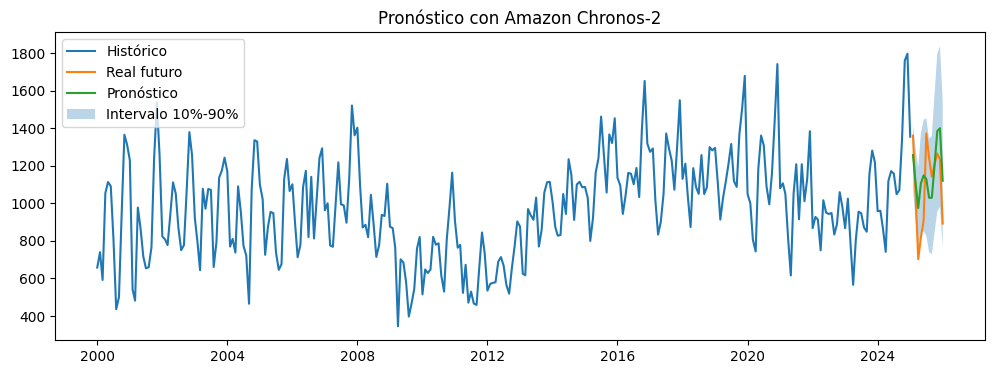

In [12]:
plt.figure(figsize=(12, 4))

plt.plot(context_df["Fecha"], context_df["Producción"], label="Histórico")
plt.plot(future_real["Fecha"], future_real["Producción"], label="Real futuro")
plt.plot(pred_df["Fecha"], pred_df["predictions"], label="Pronóstico")

plt.fill_between(
    pred_df["Fecha"],
    pred_df["0.1"],
    pred_df["0.9"],
    alpha=0.3,
    label="Intervalo 10%-90%"
)

plt.legend()
plt.title("Pronóstico con Amazon Chronos-2")
plt.show()